# 2: SQL Cohort Analysis (PostgreSQL)

**KKBox Subscription Churn Analysis**

This notebook loads the KKBox dataset into a local PostgreSQL instance and runs cohort / churn analytics entirely in SQL.
Key SQL techniques demonstrated: **CTEs, window functions (`LAG`, `ROW_NUMBER`, `RANK`), date arithmetic, `DATE_TRUNC` cohort bucketing, and `FILTER` aggregations.**

---

## 0. Setup & Database Connection

In [1]:
import os, warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

# Postgres connection parameters

DB_USER = "postgres"
DB_PASS = "1234"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "kkbox"

engine = create_engine(
    f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

with engine.connect() as conn:
    result = conn.execute(text("SELECT version();"))
    print(result.fetchone()[0])

print("\nConnected to PostgreSQL")

PostgreSQL 18.1 on x86_64-windows, compiled by msvc-19.44.35221, 64-bit

Connected to PostgreSQL


## 1. Create Tables & Load CSVs

We define the schema explicitly to enforce correct types, then bulk-load with `COPY`.
>Run this section once. Re-running is safe because of `DROP TABLE IF EXISTS`.

In [2]:
DATA_DIR = r"C:\Users\Santiago\Documents\Data Analysis\KKbox Project\data"

ddl = """
DROP TABLE IF EXISTS train       CASCADE;
DROP TABLE IF EXISTS user_logs   CASCADE;
DROP TABLE IF EXISTS transactions CASCADE;
DROP TABLE IF EXISTS members     CASCADE;

CREATE TABLE members (
    msno                    TEXT PRIMARY KEY,
    city                    INT,
    bd                      INT,
    gender                  TEXT,
    registered_via          INT,
    registration_init_time  DATE
);

CREATE TABLE transactions (
    msno                    TEXT,
    payment_method_id       INT,
    payment_plan_days       INT,
    plan_list_price         INT,
    actual_amount_paid      INT,
    is_auto_renew           SMALLINT,
    transaction_date        DATE,
    membership_expire_date  DATE,
    is_cancel               SMALLINT
);

CREATE TABLE user_logs (
    msno        TEXT,
    date        DATE,
    num_25      INT,
    num_50      INT,
    num_75      INT,
    num_985     INT,
    num_100     INT,
    num_unq     INT,
    total_secs  NUMERIC(12,4)
);

CREATE TABLE train (
    msno      TEXT PRIMARY KEY,
    is_churn  SMALLINT
);
"""

with engine.connect() as conn:
    conn.execute(text("COMMIT;"))
    for stmt in ddl.split(";"):
        s = stmt.strip()
        if s:
            conn.execute(text(s))
    conn.commit()
print("Tables created")

Tables created


In [3]:
import csv, io, psycopg2

raw_conn = psycopg2.connect(
    dbname=DB_NAME, user=DB_USER, password=DB_PASS,
    host=DB_HOST, port=DB_PORT
)
raw_conn.autocommit = True
cur = raw_conn.cursor()

def load_csv(table, filepath, date_cols=None):
    """Load CSV into Postgres via COPY, converting YYYYMMDD dates."""
    date_cols = date_cols or []
    with open(filepath, "r", encoding="utf-8") as f:
        reader = csv.reader(f)
        header = next(reader)
        date_idxs = [header.index(c) for c in date_cols if c in header]
        buf = io.StringIO()
        for row in reader:
            for i in date_idxs:
                v = row[i].strip()
                if len(v) == 8 and v.isdigit():
                    row[i] = f"{v[:4]}-{v[4:6]}-{v[6:8]}"
                elif v == "" or v.lower() == "nan":
                    row[i] = ""
            buf.write("\t".join(row) + "\n")
        buf.seek(0)
        cur.copy_from(buf, table, sep="\t", null="")
    cur.execute(f"SELECT COUNT(*) FROM {table};")
    print(f"  {table:15s}  ->  {cur.fetchone()[0]:>12,} rows")

import os
DATA = r"C:\Users\Santiago\Documents\Data Analysis\KKbox Project\data"

print("Loading CSVs ...")
load_csv("members",      os.path.join(DATA, "members_v3.csv"),
         date_cols=["registration_init_time"])
load_csv("transactions", os.path.join(DATA, "transactions_v2.csv"),
         date_cols=["transaction_date", "membership_expire_date"])
load_csv("user_logs",    os.path.join(DATA, "user_logs_v2.csv"),
         date_cols=["date"])
load_csv("train",        os.path.join(DATA, "train_v2.csv"))

print("\n All CSVs loaded")
cur.close()
raw_conn.close()

Loading CSVs ...
  members          ->     6,769,473 rows
  transactions     ->     1,431,009 rows
  user_logs        ->    18,396,362 rows
  train            ->       970,960 rows

 All CSVs loaded


In [4]:
index_sql = '''
CREATE INDEX IF NOT EXISTS idx_txn_msno       ON transactions (msno);
CREATE INDEX IF NOT EXISTS idx_txn_date       ON transactions (transaction_date);
CREATE INDEX IF NOT EXISTS idx_txn_expire     ON transactions (membership_expire_date);
CREATE INDEX IF NOT EXISTS idx_logs_msno      ON user_logs (msno);
CREATE INDEX IF NOT EXISTS idx_logs_date      ON user_logs (date);
CREATE INDEX IF NOT EXISTS idx_members_regvia ON members (registered_via);
'''
with engine.connect() as conn:
    for stmt in index_sql.strip().split(";"):
        s = stmt.strip()
        if s:
            conn.execute(text(s))
    conn.commit()
print("Indexes built")

Indexes built


In [5]:
def run_sql(query: str) -> pd.DataFrame:
    """Execute SQL and return a DataFrame."""
    with engine.connect() as conn:
        return pd.read_sql(text(query), conn)

## 2. Monthly Churn Rate

**Goal:** For each calendar month, what share of expiring memberships actually churned?

A user's membership "expires" in a given month if `membership_expire_date` falls in that month.
We join to the `train` table for the churn label, then compute the rate.

**SQL highlights:** `DATE_TRUNC`, CTE, `FILTER` clause, `LAG` window function for MoM change.

In [6]:
monthly_churn_sql = '''
WITH last_txn AS (
    -- Deduplicate: keep each user s LATEST transaction
    SELECT *
    FROM (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY msno
                   ORDER BY transaction_date DESC
               ) AS rn
        FROM transactions
    ) sub
    WHERE rn = 1
),
monthly AS (
    SELECT
        DATE_TRUNC('month', lt.membership_expire_date)::DATE  AS expire_month,
        COUNT(*)                                              AS total_expiring,
        COUNT(*) FILTER (WHERE t.is_churn = 1)                AS churned,
        ROUND(
            100.0 * COUNT(*) FILTER (WHERE t.is_churn = 1)
                  / NULLIF(COUNT(*), 0), 2
        )                                                     AS churn_rate_pct
    FROM last_txn lt
    JOIN train t ON lt.msno = t.msno
    GROUP BY 1
)
SELECT
    expire_month,
    total_expiring,
    churned,
    churn_rate_pct,
    LAG(churn_rate_pct) OVER (ORDER BY expire_month) AS prev_month_rate,
    ROUND(
        churn_rate_pct
        - LAG(churn_rate_pct) OVER (ORDER BY expire_month), 2
    ) AS mom_change_pp
FROM monthly
WHERE expire_month >= '2015-01-01'
  AND expire_month <  '2017-04-01'
ORDER BY expire_month;
'''

df_monthly = run_sql(monthly_churn_sql)
df_monthly

,expire_month,total_expiring,churned,churn_rate_pct,prev_month_rate,mom_change_pp
0,2017-02-01,11,9,81.82,NaN,NaN
1,2017-03-01,28674,16462,57.41,81.82,-24.41


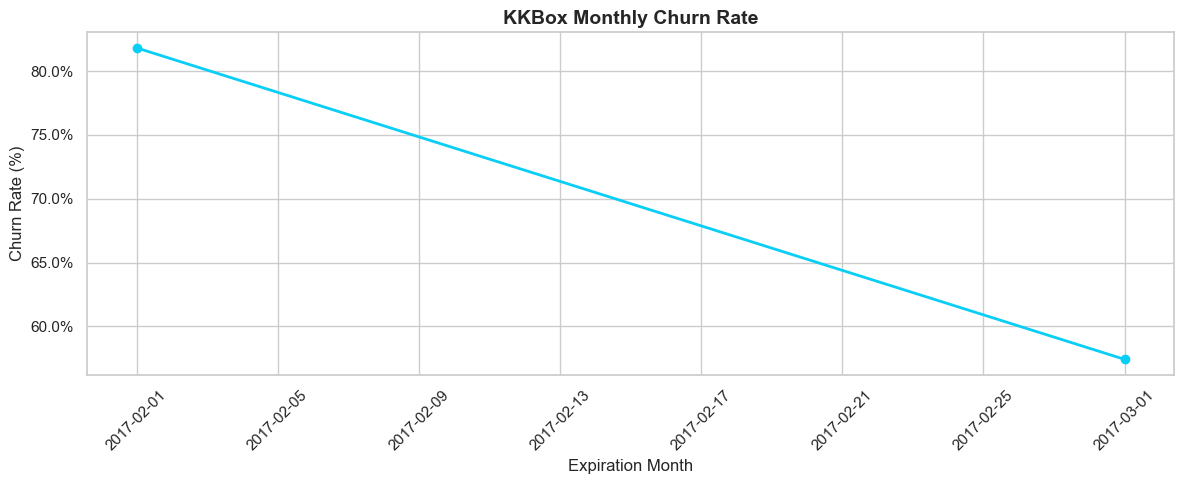

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_monthly["expire_month"], df_monthly["churn_rate_pct"],
        marker="o", linewidth=2, color = "#09CEF6")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("KKBox Monthly Churn Rate", fontsize=14, weight="bold")
ax.set_xlabel("Expiration Month")
ax.set_ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Cohort Retention Analysis

**Goal:** Group users by their *registration month* (cohort), then measure what fraction had an active transaction at 1, 3, 6, and 12 months after sign-up.

**SQL highlights:** `DATE_TRUNC` cohort bucketing, conditional `COUNT(DISTINCT ... CASE)` aggregations, interval arithmetic.

In [8]:
cohort_sql = '''
WITH cohort AS (
    SELECT
        msno,
        DATE_TRUNC('month', registration_init_time)::DATE AS cohort_month
    FROM members
    WHERE registration_init_time >= '2012-01-01'
),
txn_months AS (
    SELECT
        msno,
        DATE_TRUNC('month', transaction_date)::DATE AS txn_month
    FROM transactions
)
SELECT
    c.cohort_month,
    COUNT(DISTINCT c.msno)  AS cohort_size,
    COUNT(DISTINCT CASE WHEN t.txn_month = c.cohort_month                          THEN t.msno END) AS month_0,
    COUNT(DISTINCT CASE WHEN t.txn_month = c.cohort_month + INTERVAL '1 month'     THEN t.msno END) AS month_1,
    COUNT(DISTINCT CASE WHEN t.txn_month = c.cohort_month + INTERVAL '3 months'    THEN t.msno END) AS month_3,
    COUNT(DISTINCT CASE WHEN t.txn_month = c.cohort_month + INTERVAL '6 months'    THEN t.msno END) AS month_6,
    COUNT(DISTINCT CASE WHEN t.txn_month = c.cohort_month + INTERVAL '12 months'   THEN t.msno END) AS month_12,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN t.txn_month = c.cohort_month + INTERVAL '1 month'   THEN t.msno END)
          / NULLIF(COUNT(DISTINCT CASE WHEN t.txn_month = c.cohort_month THEN t.msno END), 0), 1) AS ret_1m_pct,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN t.txn_month = c.cohort_month + INTERVAL '3 months'  THEN t.msno END)
          / NULLIF(COUNT(DISTINCT CASE WHEN t.txn_month = c.cohort_month THEN t.msno END), 0), 1) AS ret_3m_pct,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN t.txn_month = c.cohort_month + INTERVAL '6 months'  THEN t.msno END)
          / NULLIF(COUNT(DISTINCT CASE WHEN t.txn_month = c.cohort_month THEN t.msno END), 0), 1) AS ret_6m_pct,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN t.txn_month = c.cohort_month + INTERVAL '12 months' THEN t.msno END)
          / NULLIF(COUNT(DISTINCT CASE WHEN t.txn_month = c.cohort_month THEN t.msno END), 0), 1) AS ret_12m_pct
FROM cohort c
LEFT JOIN txn_months t ON c.msno = t.msno
GROUP BY c.cohort_month
HAVING COUNT(DISTINCT CASE WHEN t.txn_month = c.cohort_month THEN t.msno END) > 50
ORDER BY c.cohort_month;
'''

df_cohort = run_sql(cohort_sql)
df_cohort.head(20)

,cohort_month,cohort_size,month_0,month_1,month_3,month_6,month_12,ret_1m_pct,ret_3m_pct,ret_6m_pct,ret_12m_pct
0,2016-02-01,208170,609,241,58,71,1074,39.6,9.5,11.7,176.4
1,2016-03-01,195618,786,200,56,172,18941,25.4,7.1,21.9,2409.8
2,2016-04-01,178329,671,138,47,265,0,20.6,7.0,39.5,0.0
3,2016-05-01,184404,554,142,58,264,0,25.6,10.5,47.7,0.0
4,2016-06-01,189359,511,142,89,301,0,27.8,17.4,58.9,0.0
5,2016-07-01,189273,563,145,123,438,0,25.8,21.8,77.8,0.0
6,2016-08-01,176584,573,203,136,893,0,35.4,23.7,155.8,0.0
7,2016-09-01,163065,704,332,168,12595,0,47.2,23.9,1789.1,0.0
8,2016-10-01,170302,1108,513,308,0,0,46.3,27.8,0.0,0.0
9,2016-11-01,165057,1213,547,659,0,0,45.1,54.3,0.0,0.0


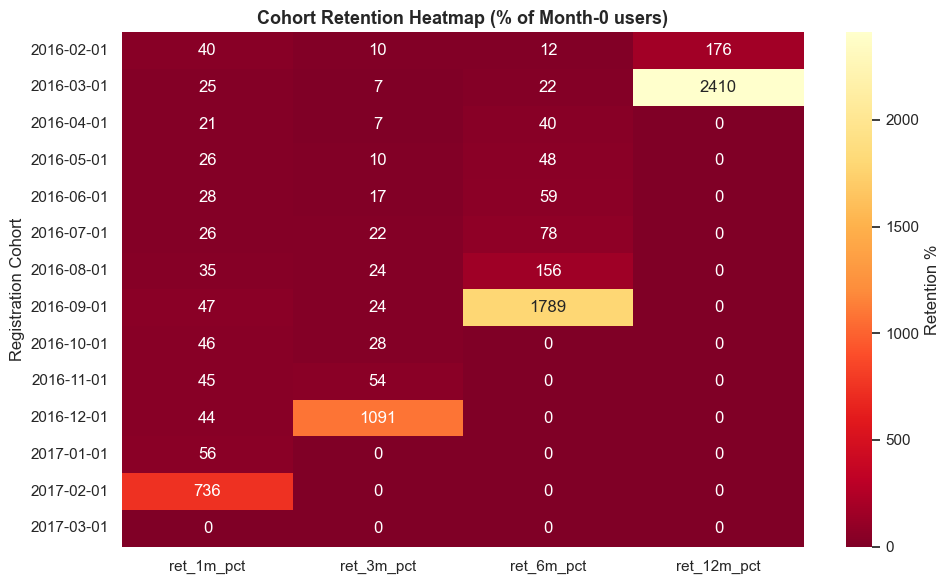

In [9]:
# Heatmap of retention rates

ret_cols = ["ret_1m_pct", "ret_3m_pct", "ret_6m_pct", "ret_12m_pct"]
heat_df = df_cohort.set_index("cohort_month")[ret_cols].dropna(how="all")
heat_df = heat_df[heat_df["ret_12m_pct"].notna()].tail(24)

fig, ax = plt.subplots(figsize=(10, max(6, len(heat_df)*0.35)))
sns.heatmap(
    heat_df.astype(float), annot=True, fmt=".0f", cmap="YlOrRd_r",
    cbar_kws={"label": "Retention %"}, ax=ax
)
ax.set_title("Cohort Retention Heatmap (% of Month-0 users)", fontsize=13, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Registration Cohort")
plt.tight_layout()
plt.show()

## 4. Churn Rate by Segment

Break down churn rate across three key dimensions:
1. **Payment plan length** (30 / 90 / 180 / 365 days)
2. **Auto-renew status** (on vs. off)
3. **Registration channel**

**SQL highlights:** `FILTER` clause, `CASE` bucketing, `DISTINCT ON` for latest-row dedup.

In [10]:
# Churn by plan length

plan_churn_sql = '''
WITH latest_txn AS (
    SELECT DISTINCT ON (msno) *
    FROM transactions
    ORDER BY msno, transaction_date DESC
)
SELECT
    CASE
        WHEN lt.payment_plan_days <= 30  THEN '30d'
        WHEN lt.payment_plan_days <= 90  THEN '90d'
        WHEN lt.payment_plan_days <= 180 THEN '180d'
        WHEN lt.payment_plan_days <= 365 THEN '365d'
        ELSE 'other'
    END                                                   AS plan_bucket,
    COUNT(*)                                              AS users,
    COUNT(*) FILTER (WHERE t.is_churn = 1)                AS churned,
    ROUND(100.0 * COUNT(*) FILTER (WHERE t.is_churn = 1)
          / NULLIF(COUNT(*), 0), 2)                       AS churn_rate_pct
FROM latest_txn lt
JOIN train t ON lt.msno = t.msno
GROUP BY 1
ORDER BY churn_rate_pct DESC;
'''
df_plan = run_sql(plan_churn_sql)
df_plan

,plan_bucket,users,churned,churn_rate_pct
0,other,4978,4952,99.48
1,180d,3754,3729,99.33
2,365d,4754,4710,99.07
3,90d,4201,3802,90.50
4,30d,915891,40702,4.44


In [11]:
# Churn by auto-renew

autorenew_sql = '''
WITH latest_txn AS (
    SELECT DISTINCT ON (msno) *
    FROM transactions
    ORDER BY msno, transaction_date DESC
)
SELECT
    CASE lt.is_auto_renew
        WHEN 1 THEN 'Auto-Renew ON'
        ELSE        'Auto-Renew OFF'
    END                                                   AS auto_renew_status,
    COUNT(*)                                              AS users,
    COUNT(*) FILTER (WHERE t.is_churn = 1)                AS churned,
    ROUND(100.0 * COUNT(*) FILTER (WHERE t.is_churn = 1)
          / NULLIF(COUNT(*), 0), 2)                       AS churn_rate_pct
FROM latest_txn lt
JOIN train t ON lt.msno = t.msno
GROUP BY 1
ORDER BY churn_rate_pct DESC;
'''
df_autorenew = run_sql(autorenew_sql)
df_autorenew

,auto_renew_status,users,churned,churn_rate_pct
0,Auto-Renew OFF,82909,25343,30.57
1,Auto-Renew ON,850669,32552,3.83


In [12]:
#Churn by registration channel
regchannel_sql = '''
WITH latest_txn AS (
    SELECT DISTINCT ON (msno) *
    FROM transactions
    ORDER BY msno, transaction_date DESC
)
SELECT
    m.registered_via,
    COUNT(*)                                              AS users,
    COUNT(*) FILTER (WHERE t.is_churn = 1)                AS churned,
    ROUND(100.0 * COUNT(*) FILTER (WHERE t.is_churn = 1)
          / NULLIF(COUNT(*), 0), 2)                       AS churn_rate_pct
FROM latest_txn lt
JOIN train t   ON lt.msno = t.msno
JOIN members m ON lt.msno = m.msno
GROUP BY 1
ORDER BY churn_rate_pct DESC;
'''
df_regchan = run_sql(regchannel_sql)
df_regchan

,registered_via,users,churned,churn_rate_pct
0,4,45415,6666,14.68
1,3,96194,10725,11.15
2,9,222338,19595,8.81
3,13,3329,274,8.23
4,7,458092,16517,3.61


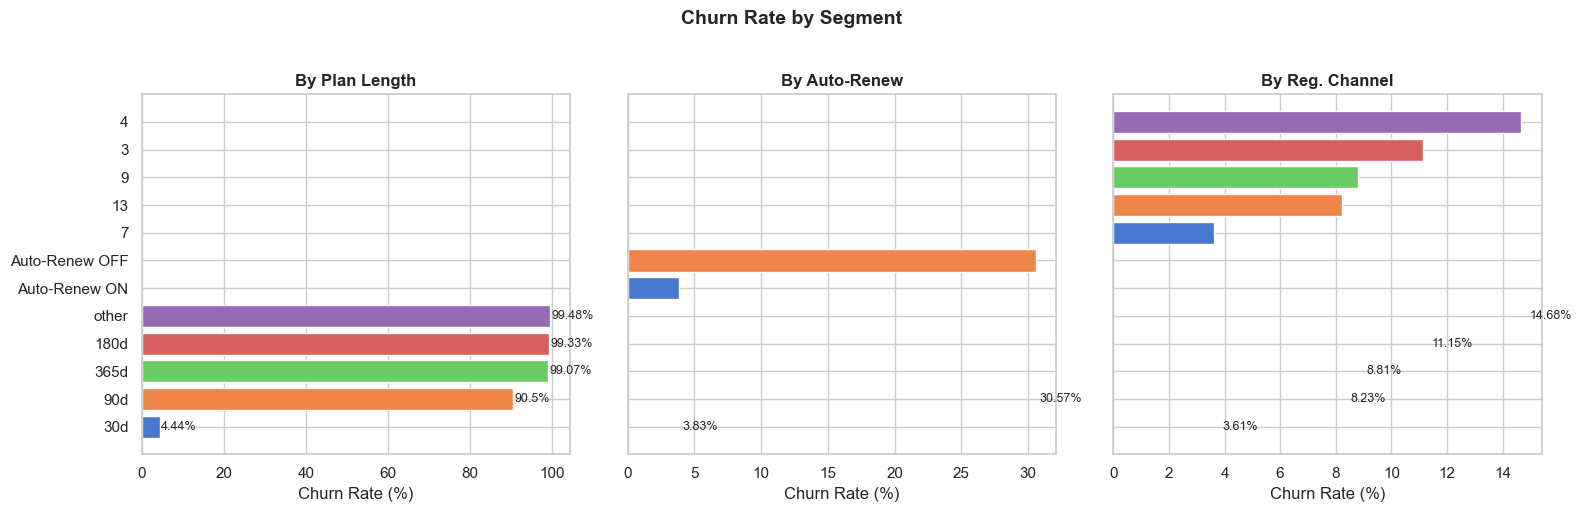

In [13]:
# Combined segment bar chart

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (df, col, title) in zip(axes, [
    (df_plan,      "plan_bucket",        "By Plan Length"),
    (df_autorenew, "auto_renew_status",  "By Auto-Renew"),
    (df_regchan,   "registered_via",     "By Reg. Channel"),
]):
    df = df.sort_values("churn_rate_pct", ascending=True)
    ax.barh(df[col].astype(str), df["churn_rate_pct"], color=sns.color_palette("muted"))
    ax.set_xlabel("Churn Rate (%)")
    ax.set_title(title, weight="bold")
    for i, v in enumerate(df["churn_rate_pct"]):
        ax.text(v + 0.3, i, f"{v}%", va="center", fontsize=9)

fig.suptitle("Churn Rate by Segment", fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 5. Listening Behavior Decay (Pre-Churn Signal)

**Goal:** For churned vs. retained users, I compared average daily listening seconds in the 4 weeks leading up to their membership expiry.
If churned users show a steeper drop-off, this is a strong *predictive* signal.

**SQL highlights:** Window over weekly buckets, date arithmetic with `INTERVAL`, conditional aggregation, `PERCENTILE_CONT`.

In [14]:
decay_sql = '''
WITH last_txn AS (
    SELECT DISTINCT ON (msno) msno, membership_expire_date
    FROM transactions
    ORDER BY msno, transaction_date DESC
),
labeled AS (
    SELECT
        lt.msno,
        lt.membership_expire_date,
        t.is_churn,
        CASE t.is_churn WHEN 1 THEN 'Churned' ELSE 'Retained' END AS churn_label
    FROM last_txn lt
    JOIN train t ON lt.msno = t.msno
),
weekly_listening AS (
    SELECT
        l.msno,
        l.churn_label,
        CASE
            WHEN ul.date BETWEEN l.membership_expire_date - INTERVAL '7 days'
                              AND l.membership_expire_date            THEN 'Week 1 (final)'
            WHEN ul.date BETWEEN l.membership_expire_date - INTERVAL '14 days'
                              AND l.membership_expire_date - INTERVAL '8 days'  THEN 'Week 2'
            WHEN ul.date BETWEEN l.membership_expire_date - INTERVAL '21 days'
                              AND l.membership_expire_date - INTERVAL '15 days' THEN 'Week 3'
            WHEN ul.date BETWEEN l.membership_expire_date - INTERVAL '28 days'
                              AND l.membership_expire_date - INTERVAL '22 days' THEN 'Week 4'
        END AS week_bucket,
        ul.total_secs
    FROM labeled l
    JOIN user_logs ul ON l.msno = ul.msno
    WHERE ul.date BETWEEN l.membership_expire_date - INTERVAL '28 days'
                       AND l.membership_expire_date
)
SELECT
    churn_label,
    week_bucket,
    COUNT(DISTINCT msno)            AS users,
    ROUND(AVG(total_secs), 1)       AS avg_daily_secs,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY total_secs)::NUMERIC, 1) AS median_daily_secs
FROM weekly_listening
WHERE week_bucket IS NOT NULL
GROUP BY churn_label, week_bucket
ORDER BY churn_label, week_bucket DESC;
'''

df_decay = run_sql(decay_sql)
df_decay

,churn_label,week_bucket,users,avg_daily_secs,median_daily_secs
0,Churned,Week 4,13442,7945.6,4788.3
1,Churned,Week 3,12874,7727.5,4577.9
2,Churned,Week 2,11944,7396.2,4339.6
3,Churned,Week 1 (final),10547,6898.3,3890.1
4,Retained,Week 4,458242,7643.0,4468.0
5,Retained,Week 3,343087,7626.1,4470.2
6,Retained,Week 2,217291,7584.5,4454.9
7,Retained,Week 1 (final),101160,7386.3,4355.1


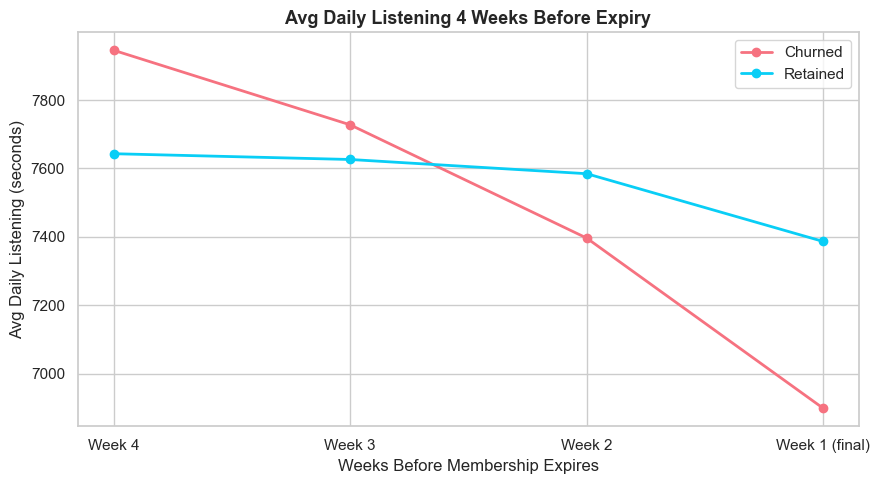

In [15]:
# Plot listening decay

fig, ax = plt.subplots(figsize=(9, 5))
week_order = ["Week 4", "Week 3", "Week 2", "Week 1 (final)"]
for label, grp in df_decay.groupby("churn_label"):
    grp = grp.set_index("week_bucket").reindex(week_order)
    ax.plot(grp.index, grp["avg_daily_secs"], marker="o", linewidth=2, label=label, color = "#09CEF6" if label == "Retained" else "#F67280")

ax.set_title("Avg Daily Listening 4 Weeks Before Expiry", fontsize=13, weight="bold")
ax.set_xlabel("Weeks Before Membership Expires")
ax.set_ylabel("Avg Daily Listening (seconds)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Feature Engineering via SQL

Here is a **per-user feature table** that feeds the Python churn model in Notebook 03.

| Feature | Description |
|---------|-------------|
| `days_since_last_txn` | Days between last transaction and membership expiry |
| `num_cancellations` | Count of `is_cancel = 1` transactions |
| `auto_renew_rate` | Share of transactions with auto-renew on |
| `avg_discount_pct` | Average discount relative to list price |
| `plan_days_last` | Most recent plan length |
| `log_days_last_30` | Active listening days in final 30-day window |
| `avg_daily_secs_last_30` | Mean daily seconds in final 30 days |
| `completion_rate_last_30` | % of songs completed (num_100 / total plays) |

**SQL highlights:** Multiple CTEs feeding a single `SELECT`, window functions for "latest" row, `FILTER` aggregation, date arithmetic.

In [17]:
feature_sql = '''
WITH last_txn AS (
    SELECT DISTINCT ON (msno) *
    FROM transactions
    ORDER BY msno, transaction_date DESC
),
txn_features AS (
    SELECT
        msno,
        (membership_expire_date - transaction_date)  AS days_since_last_txn,
        payment_plan_days                            AS plan_days_last,
        is_auto_renew                                AS auto_renew_last
    FROM last_txn
),
cancellation_counts AS (
    SELECT
        msno,
        COUNT(*) FILTER (WHERE is_cancel = 1)        AS num_cancellations,
        ROUND(AVG(is_auto_renew::NUMERIC), 4)        AS auto_renew_rate,
        ROUND(AVG(
            CASE WHEN plan_list_price > 0
                 THEN 1.0 - (actual_amount_paid::NUMERIC / plan_list_price)
                 ELSE 0 END
        ), 4)                                        AS avg_discount_pct
    FROM transactions
    GROUP BY msno
),
log_features AS (
    SELECT
        lt.msno,
        COUNT(ul.date)                               AS log_days_last_30,
        ROUND(AVG(ul.total_secs), 2)                 AS avg_daily_secs_last_30,
        ROUND(AVG(
            CASE WHEN (ul.num_25 + ul.num_50 + ul.num_75 + ul.num_985 + ul.num_100) > 0
                 THEN ul.num_100::NUMERIC
                      / (ul.num_25 + ul.num_50 + ul.num_75 + ul.num_985 + ul.num_100)
                 ELSE NULL END
        ), 4)                                        AS completion_rate_last_30
    FROM last_txn lt
    JOIN user_logs ul
        ON lt.msno = ul.msno
       AND ul.date BETWEEN lt.membership_expire_date - INTERVAL '30 days'
                        AND lt.membership_expire_date
    GROUP BY lt.msno
)
SELECT
    tf.msno,
    tf.days_since_last_txn,
    tf.plan_days_last,
    tf.auto_renew_last,
    COALESCE(cc.num_cancellations, 0)       AS num_cancellations,
    COALESCE(cc.auto_renew_rate, 0)         AS auto_renew_rate,
    COALESCE(cc.avg_discount_pct, 0)        AS avg_discount_pct,
    COALESCE(lf.log_days_last_30, 0)        AS log_days_last_30,
    COALESCE(lf.avg_daily_secs_last_30, 0)  AS avg_daily_secs_last_30,
    COALESCE(lf.completion_rate_last_30, 0) AS completion_rate_last_30,
    t.is_churn
FROM txn_features tf
JOIN train t             ON tf.msno = t.msno
LEFT JOIN cancellation_counts cc ON tf.msno = cc.msno
LEFT JOIN log_features lf        ON tf.msno = lf.msno;
'''

df_features = run_sql(feature_sql)
print(f"Feature table: {df_features.shape[0]:,} users x {df_features.shape[1]} columns")
df_features.head(10)

Feature table: 933,578 users x 11 columns


,msno,days_since_last_txn,plan_days_last,auto_renew_last,num_cancellations,auto_renew_rate,avg_discount_pct,log_days_last_30,avg_daily_secs_last_30,completion_rate_last_30,is_churn
0,//LNUhWtamiEonDJaM9O0hu7xxs/j3tMaxySZxd8TTY=,31,30,1,0,1.0,0.0,0,0.00,0.0000,0
1,//oTOh37hfJnouJhiAXqf6jnRuluWINHB0KE29mUII4=,30,30,1,0,1.0,0.0,28,6792.47,0.7478,0
2,//UqgHWjM+Vf0T7/IF4L0CNHaSFPOME0xd6ukFVC6b8=,30,30,1,0,1.0,0.0,0,0.00,0.0000,0
3,/+C1Lb0Q/4A24pGJEAnGsb7GfW8BIwEJZpV3xOAlfY4=,31,30,1,0,1.0,0.0,6,3879.33,0.6111,0
4,/+CaXsmQ4x86MXQoCKMqsGs/6Ndziu5aTRgeeW8ItXM=,32,30,1,0,1.0,0.0,14,8783.59,0.6979,0
5,/+PBQitZGcJ7ASeZeHEAUCMOkCJqhvNVfRuREM6lVE4=,32,30,1,0,1.0,0.0,12,3927.58,0.6766,0
6,/+PF+hhya3wgOEMygfVjNkEBULs5qlsR1D0GUomlljs=,31,30,1,0,1.0,0.0,6,4310.63,0.6318,0
7,/01jjQ839MjZRQBn1mtBNi2pZksuzGx5deuA8z0Ch4E=,31,30,1,0,1.0,0.0,23,4151.40,0.5906,0
8,/09a29kwgm3hya11YQ7KR5TkXsROXeoK270SLRvxPc4=,31,30,1,0,1.0,0.0,0,0.00,0.0000,0
9,/0HyGsG+8ruU4/A+Zxh/Aq6+QRlrUgTojyzbQReNzf4=,30,30,1,0,1.0,0.0,0,0.00,0.0000,0


In [18]:
# mean features by churn label

df_features.groupby("is_churn")[
    ["days_since_last_txn", "num_cancellations", "auto_renew_rate",
     "avg_discount_pct", "log_days_last_30", "avg_daily_secs_last_30",
     "completion_rate_last_30"]
].mean().round(3).T

is_churn,0,1
days_since_last_txn,32.112,123.749
num_cancellations,0.015,0.338
auto_renew_rate,0.935,0.568
avg_discount_pct,0.001,0.016
log_days_last_30,5.922,3.764
avg_daily_secs_last_30,4043.313,2307.467
completion_rate_last_30,0.438,0.249


In [19]:
# Save feature table for Notebook 03

import os
OUT_DIR = r"C:\Users\Santiago\Documents\Data Analysis\KKbox Project\data"
out_path = os.path.join(OUT_DIR, "features_from_sql.parquet")
df_features.to_parquet(out_path, index=False)
print(f"\n  Saved -> {out_path}  ({df_features.shape[0]:,} rows)")


  Saved -> C:\Users\Santiago\Documents\Data Analysis\KKbox Project\data\features_from_sql.parquet  (933,578 rows)


---
## Summary of SQL Techniques Demonstrated

| Technique | Where Used |
|-----------|------------|
| **CTEs** | Every query — `last_txn`, `cohort`, `labeled`, `txn_features`, etc. |
| **`ROW_NUMBER()`** | Deduplicating to latest transaction (§2, §4, §5, §6) |
| **`DISTINCT ON`** | PostgreSQL shorthand for latest-row dedup (§4, §5, §6) |
| **`LAG()`** | Month-over-month churn rate change (§2) |
| **`DATE_TRUNC`** | Cohort bucketing by registration month (§3), monthly aggregation (§2) |
| **`FILTER` clause** | Conditional aggregation without `CASE` (§2, §4, §6) |
| **Date arithmetic** | Interval-based weekly buckets (§5), 30-day windows (§6) |
| **`PERCENTILE_CONT`** | Median listening seconds (§5) |
| **Multi-CTE pipeline** | Feature engineering — 4 CTEs into one SELECT (§6) |

**Next** → `03_feature_engineering.ipynb` picks up `features_from_sql.parquet` for Python modeling.